In [4]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import xgboost
from pathlib import Path

In [6]:
import sys
sys.path.insert(0, "/project/Wellcome_Discovery/lturiano/GENESIS")

from utils import MARKERS

ModuleNotFoundError: No module named 'utils'

In [31]:
np.random.seed(42)

In [32]:
BASE = Path("/project/Wellcome_Discovery/datashare/lturiano/GENESIS/data")

organ = "heart"            # a string
organ_path = BASE / organ  # use / to join
print(organ_path)          # prints a Path

/project/Wellcome_Discovery/datashare/lturiano/GENESIS/data/heart


In [34]:
rna = sc.read_h5ad(BASE / organ / f"{organ}_sc_filt.h5ad")
gex = sc.read_h5ad(BASE / organ / f"{organ}_sn_filt.h5ad")
fake = sc.read_h5ad(BASE / organ / f"{organ}_Fake_RNA_VAE_UNET_log.h5ad")

In [78]:
celltype_col = "cell_type"  # change if your column name differs

df_counts = (
    rna.obs[celltype_col]
    .value_counts()
    .rename_axis("cell_type")
    .reset_index(name="n_samples")
)

display(df_counts)

,cell_type,n_samples
0,endothelial cell,52171
1,mural_cell,22641
2,myeloid cell,14702
3,lymphocyte,11945
4,fibroblast,3163


In [35]:
marker_genes = {
    "endothelial cell": ["PECAM1", "VWF", "KDR", "CLDN5", "ENG"],
    "fibroblast": ["COL1A1", "COL1A2", "DCN", "LUM", "PDGFRA"],
    "lymphocyte": ["PTPRC", "CD3D", "CD3E", "IL7R", "CD2"],
    "mural_cell": ["RGS5", "PDGFRB", "ACTA2", "TAGLN", "MYH11"],
    "myeloid cell": ["LYZ", "CD68", "CSF1R", "HLA-DRA", "ITGAM"]
}

In [36]:
genes = []

for row in list(marker_genes.values()):
    for item in row:
        if item not in genes:
            genes.append(item)
            
np.random.shuffle(genes)

In [37]:
df_rna = pd.DataFrame(index   = rna.obs.index,
                      columns = genes,
                      data    = rna.X[:, rna.var.feature_name.isin(genes)])

df_gex = pd.DataFrame(index   = gex.obs.index,
                      columns = genes,
                      data    = gex.X[:, gex.var.feature_name.isin(genes)])

df_fake = pd.DataFrame(index   = fake.obs.index,
                       columns = genes,
                       data    = fake.X[:, fake.var.feature_name.isin(genes)])

In [67]:
# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(rna.obs["cell_type"].values.tolist())
label_encoder.classes_

array(['endothelial cell', 'fibroblast', 'lymphocyte', 'mural_cell',
       'myeloid cell'], dtype='<U16')

In [66]:
df_rna["cell_type"]  = label_encoder.transform(rna.obs["cell_type"].values.tolist())
df_gex["cell_type"]  = label_encoder.transform(gex.obs["cell_type"].values.tolist())
df_fake["cell_type"] = label_encoder.transform(rna.obs["cell_type"].values.tolist())

In [40]:
# Create train-test split (final evaluation set)
X_train_rna, X_test_rna, y_train_rna, y_test_rna = train_test_split(df_rna[df_rna.columns[:-1]],
                                                                    df_rna[df_rna.columns[-1]],
                                                                    test_size=0.15,
                                                                    random_state=42,
                                                                    stratify=df_rna[df_rna.columns[-1]]
                                                                    )

In [41]:
# Create train-test split (final evaluation set)
X_train_gex, X_test_gex, y_train_gex, y_test_gex = train_test_split(df_gex[df_gex.columns[:-1]],
                                                                    df_gex[df_gex.columns[-1]],
                                                                    test_size=0.15,
                                                                    random_state=42,
                                                                    stratify=df_gex[df_gex.columns[-1]]
                                                                    )

In [42]:
# Create train-test split (final evaluation set)
X_train_fake, X_test_fake, y_train_fake, y_test_fake = train_test_split(df_fake[df_fake.columns[:-1]],
                                                                        df_fake[df_fake.columns[-1]],
                                                                        test_size=0.15,
                                                                        random_state=42,
                                                                        stratify=df_fake[df_fake.columns[-1]]
                                                                        )

# Training and hyperparameter setting xgboost on scRNA

In [45]:
# Define XGBoost classifier
xgb_clf = xgboost.XGBClassifier(objective='multi:softprob',
                             num_class=len(label_encoder.classes_),
                             device="cpu",
                             random_state=42)

In [46]:
# Hyperparameter grid
param_grid = {'booster': ['gbtree', 'dart'],
              'max_depth': [2, 4, 6],
              'learning_rate': [0.01, 0.05, 0.1],
              'n_estimators': [50, 100, 150],
              'subsample': [0.6, 0.8, 1.0],
              }

In [47]:
# Cross-validation and hyperparameter tuning
clf_cv = GridSearchCV(estimator=xgb_clf,
                      param_grid=param_grid,
                      scoring='accuracy',
                      cv=5,
                      verbose=1,
                      n_jobs=8)

clf_cv.fit(X_train_rna, y_train_rna)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
[12:26:12] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:15] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:16] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:21] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:24] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:30] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:35] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:39] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:42] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:50] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:56] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:27:07] WA

[12:26:12] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:15] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:17] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:21] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:25] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:32] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:36] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:40] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:44] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:53] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:27:05] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:27:18] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not

[12:26:12] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:15] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:17] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:21] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:28] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:35] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:39] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:43] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:52] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:59] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:27:12] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:27:19] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not

[12:26:09] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:12] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:14] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:16] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:20] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:24] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:30] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:36] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:40] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:43] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:51] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:57] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not

[12:26:12] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:14] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:16] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:20] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:24] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:30] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:35] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:39] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:43] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:50] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:57] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:27:08] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not

[12:26:12] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:15] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:17] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:21] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:25] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:31] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:36] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:41] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:49] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:57] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:27:09] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:27:21] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not

[12:26:13] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:16] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:20] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:24] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:31] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:37] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:41] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:49] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:26:57] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:27:10] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:27:21] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[12:27:28] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not

[13:04:46] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.



,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'booster': ['gbtree', 'dart'], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 4, ...], 'n_estimators': [50, 100, ...], ...}"
,scoring,'accuracy'
,n_jobs,8
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [48]:
# Best hyperparameters
print("Best hyperparameters:")
print(clf_cv.best_params_)

# Evaluate on final test set
best_model = clf_cv.best_estimator_

Best hyperparameters:
{'booster': 'dart', 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 150, 'subsample': 0.6}


In [ ]:
# Best hyperparameters:
# {'booster': 'dart', 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 150, 'subsample': 0.6}

In [50]:
best_model.save_model(f'{organ}_best_xgb_model.json')

# Performance evaluation on scRNA, scGEX, generated scGEX

In [52]:
model_rna = xgboost.XGBClassifier()
model_rna.load_model(f'{organ}_best_xgb_model.json')

In [53]:
y_pred_rna = model_rna.predict(X_train_rna)
print(f'Accuracy: {accuracy_score(y_train_rna.values, y_pred_rna):.4f}')

Accuracy: 0.9822


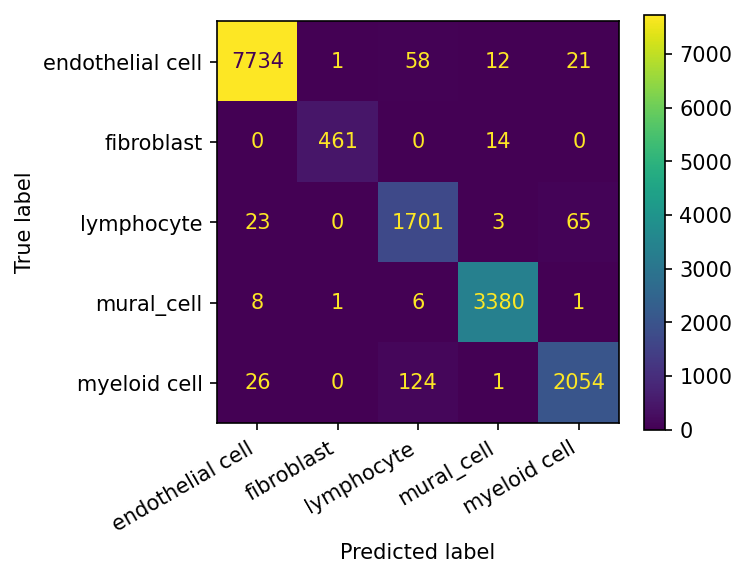

,cell_type,n_samples
0,endothelial cell,52171
1,mural_cell,22641
2,myeloid cell,14702
3,lymphocyte,11945
4,fibroblast,3163


In [81]:
class_names = list(label_encoder.classes_)  # guaranteed correct order

cm = confusion_matrix(y_test_rna, y_pred_rna, labels=np.arange(len(class_names)))

fig, ax = plt.subplots(figsize=(5, 4), dpi=150)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, values_format="d", colorbar=True)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)

fig.tight_layout()
plt.show()

display(df_counts)

In [55]:
y_pred_gex = model_rna.predict(X_test_gex)
print(f'Accuracy: {accuracy_score(y_test_gex.values, y_pred_gex):.4f}')

Accuracy: 0.8540


Number of test samples per class
endothelial cell: 7826
fibroblast: 475
lymphocyte: 1792
mural_cell: 3396
myeloid cell: 2205


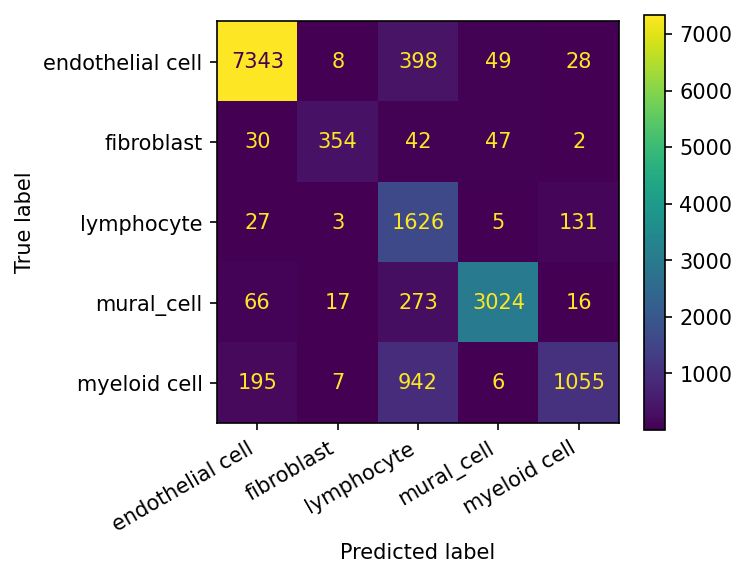

,cell_type,n_samples
0,endothelial cell,52171
1,mural_cell,22641
2,myeloid cell,14702
3,lymphocyte,11945
4,fibroblast,3163


In [89]:
class_names = list(label_encoder.classes_)  # guaranteed correct order
counts = np.bincount(y_test_fake, minlength=len(class_names))

print("Number of test samples per class")
for i, (name, n) in enumerate(zip(class_names, counts)):
    print(f"{name}: {n}")

cm = confusion_matrix(y_test_gex, y_pred_gex, labels=np.arange(len(class_names)))

fig, ax = plt.subplots(figsize=(5, 4), dpi=150)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, values_format="d", colorbar=True)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)

fig.tight_layout()
plt.show()

display(df_counts)

In [59]:
y_pred_fake = best_model.predict(X_test_fake)
print(f'Accuracy: {accuracy_score(y_test_fake, y_pred_fake):.4f}')

Accuracy: 0.8380


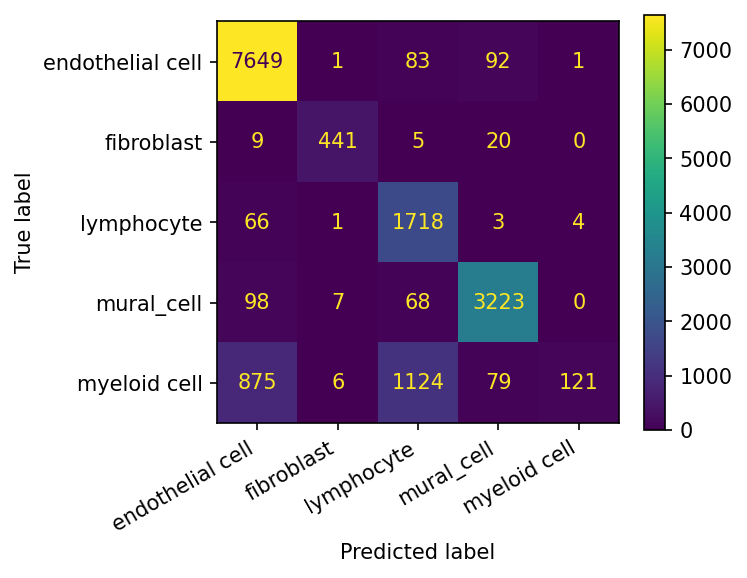

,cell_type,n_samples
0,endothelial cell,52171
1,mural_cell,22641
2,myeloid cell,14702
3,lymphocyte,11945
4,fibroblast,3163


In [79]:
class_names = list(label_encoder.classes_)  # guaranteed correct order

cm = confusion_matrix(y_test_fake, y_pred_fake, labels=np.arange(len(class_names)))

fig, ax = plt.subplots(figsize=(5, 4), dpi=150)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, values_format="d", colorbar=True)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)

fig.tight_layout()
plt.show()

display(df_counts)

# Fine-tuning on scGEX

In [49]:
model_gex = xgboost.XGBClassifier()
model_gex.load_model(f'{organ}_best_xgb_model.json')

In [50]:
model_gex.fit(X_train_gex, 
              y_train_gex,
              xgb_model=model_gex.get_booster(),  # Continue training from existing model
              verbose=True
              )

[11:24:11] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.



,objective,'multi:softprob'
,use_label_encoder,None
,base_score,None
,booster,'dart'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [51]:
y_pred_rna = model_gex.predict(X_test_rna)
print(f'Accuracy: {accuracy_score(y_test_rna.values, y_pred_rna):.4f}')

Accuracy: 0.9937


In [52]:
y_pred_gex = model_gex.predict(X_test_gex)
print(f'Accuracy: {accuracy_score(y_test_gex.values, y_pred_gex):.4f}')

Accuracy: 0.8591


In [53]:
y_pred_fake = model_gex.predict(X_test_fake)
print(f'Accuracy: {accuracy_score(y_test_fake, y_pred_fake):.4f}')

Accuracy: 0.9621


# Fine-tuning on generated scRNA

In [309]:
model_fake = xgboost.XGBClassifier()
model_fake.load_model(f'{organ}_best_xgb_model.json')

In [310]:
model_fake.fit(X_train_fake, 
               y_train_fake,
               xgb_model=model_fake.get_booster(),  # Continue training from existing model
               verbose=True
               )

[16:48:29] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.



,objective,'multi:softprob'
,use_label_encoder,None
,base_score,None
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [311]:
y_pred_rna = model_fake.predict(X_test_rna)
print(f'Accuracy: {accuracy_score(y_test_rna.values, y_pred_rna):.4f}')

Accuracy: 0.8433


In [312]:
y_pred_gex = model_fake.predict(X_test_gex)
print(f'Accuracy: {accuracy_score(y_test_gex.values, y_pred_gex):.4f}')

Accuracy: 0.1027


In [313]:
y_pred_fake = model_fake.predict(X_test_fake)
print(f'Accuracy: {accuracy_score(y_test_fake, y_pred_fake):.4f}')

Accuracy: 0.9810
[16:31:50] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:31:51] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:31:53] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:31:54] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:31:56] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:31:58] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:31:59] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:32:00] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:32:03] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:32:08] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:32:12] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:32:13] WARNING: ../src/learner.cc:767: 
Parameters: { "


[16:41:38] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:41:48] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:41:57] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:42:17] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:42:38] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:42:41] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:42:52] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:43:03] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:43:26] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:43:49] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:43:53] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:44:06] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are no


[16:42:52] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:43:03] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:43:24] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:43:48] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:43:52] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:43:56] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:44:08] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:44:20] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:44:46] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.


[16:42:45] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:42:55] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[16:43:06] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are n